In [16]:
import sys
import os
import gdsfactory as gf
sys.path.append(os.path.expanduser("~/projects/palace-course/utils"))
from verify_topology import verify, print_report
from ihp import PDK
from ihp.cells.capacitors import rfcmim
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

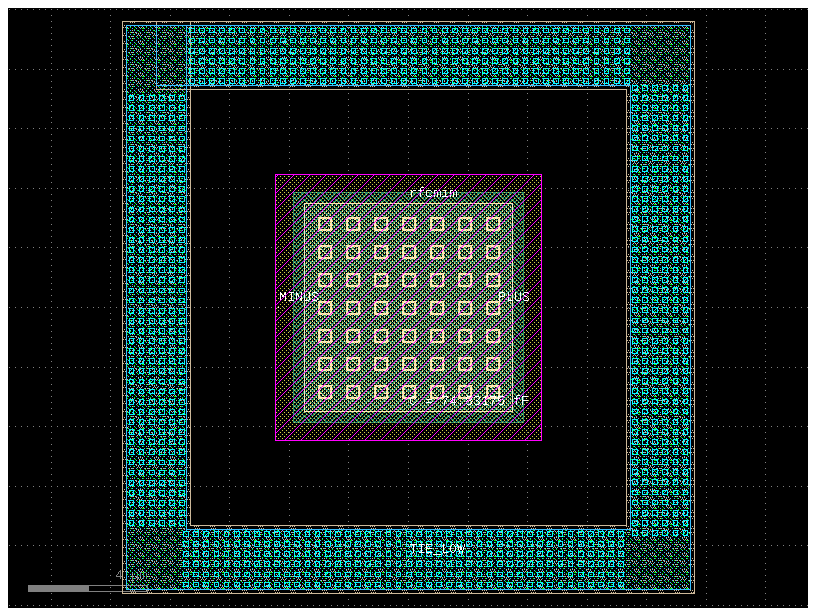

In [17]:
c = rfcmim(width=7.0, length=7.0)
c_plot = gf.Component()
for layer in c.layers:
    layer_number, datatype = layer
    if datatype != 0:
        continue
    layer_comp = c.extract(layers=[layer])
    c_plot.add_ref(layer_comp)

c_plot.draw_ports()
c_plot.plot()

In [18]:
#We exclude nofill layers
keep_layers = [
    (1, 0),    # Activdrawing
    (6, 0),    # Contdrawing
    (8, 0),    # Metal1drawing
    (8, 2),    # Metal1pin
    (14, 0),   # pSDdrawing
    (36, 0),   # MIMdrawing
    (46, 21),  # PWelldrawing
    (67, 0),   # Metal5drawing
    (67, 2),   # Metal5pin
    (69, 0),   # MemCapdrawing
    (126, 0),  # TopMetal1drawing
    (126, 2),  # TopMetal1pin
    (129, 0),  # Vmimdrawing
]

cc = c.extract(layers=keep_layers)
cc.add_ports(c.ports)

In [19]:
# Checking the port layers.
cc.ports

["Port(self.name='MINUS', self.width=200, trans=r180 *1 -4.36,0, layer=Metal5pin (67/2), port_type=electrical)", "Port(self.name='PLUS', self.width=1000, trans=r0 *1 3,0, layer=TopMetal1pin (126/2), port_type=electrical)", "Port(self.name='TIE_LOW', self.width=2000, trans=r0 *1 0,-8.46, layer=Metal1pin (8/2), port_type=electrical)"]

By inspecting `cc.ports`, we observe that the port labeled *MINUS* appears first in the component’s port ordering. In gdsfactory, this ordering determines the port indexing, so *MINUS* is automatically assigned as port P1. Therefore, it must be set with `excited=True` to ensure that Palace excites P1 and correctly computes the scattering parameters $S_{11}$ and $S_{21}$.


In [ ]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-rfcmim")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=2.0,air_above=5.0)

# MINUS is assigned as P1 by gdsfactory (component port order), so it must be
# excited=True to ensure Palace excites P1 and generates S[1][1] and S[2][1].
sim.add_port("MINUS", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True)
sim.add_port("PLUS", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=False)
sim.add_port("TIE_LOW", layer="metal1", length=2.0, geometry="inplane", excited=False)

sim.set_driven(fmin=1e9, fmax=20e9, num_points=21)

print(sim.validate_config())

Validation: PASSED


In [ ]:
#TODO: investigate why XY dimension is much larger than expected.
sim.mesh(preset="graded", refined_mesh_size=0.2)

Conductor volume 1 on active invalidated by dedup


Mesh Summary
Dimensions: 119.2 x 119.2 x 23.3 µm
Nodes:      16,905
Elements:   126,967
Tetrahedra: 98,344
Edge length: 0.00 - 49.29 µm
Quality:    0.561 (min: 0.000)
SICN:       0.602 (all valid)
----------------------------------------
Volumes (5):
  - cont [1]
  - vmim [2]
  - SiO2 [3]
  - passive [4]
  - air [5]
Surfaces (16):
  - metal5_xy [6]
  - metal5_z [7]
  - metal1_xy [8]
  - metal1_z [9]
  - topmetal1_xy [10]
  - topmetal1_z [11]
  - P1 [12]
  - P2 [13]
  - P3 [14]
  - SiO2__cont [15]
  - SiO2__vmim [16]
  - SiO2__None [17]
  - SiO2__passive [18]
  - passive__None [19]
  - air__passive [20]
  - air__None [21]
----------------------------------------
Mesh:   runs/palace-sim-rfcmim/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 03:19:54.687 ( 136.974s) [    70C1710A2080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 03:19:54.697 ( 136.983s) [    70C1710A2080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 03:19:54.754 ( 137.041s) [    70C1710A2080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


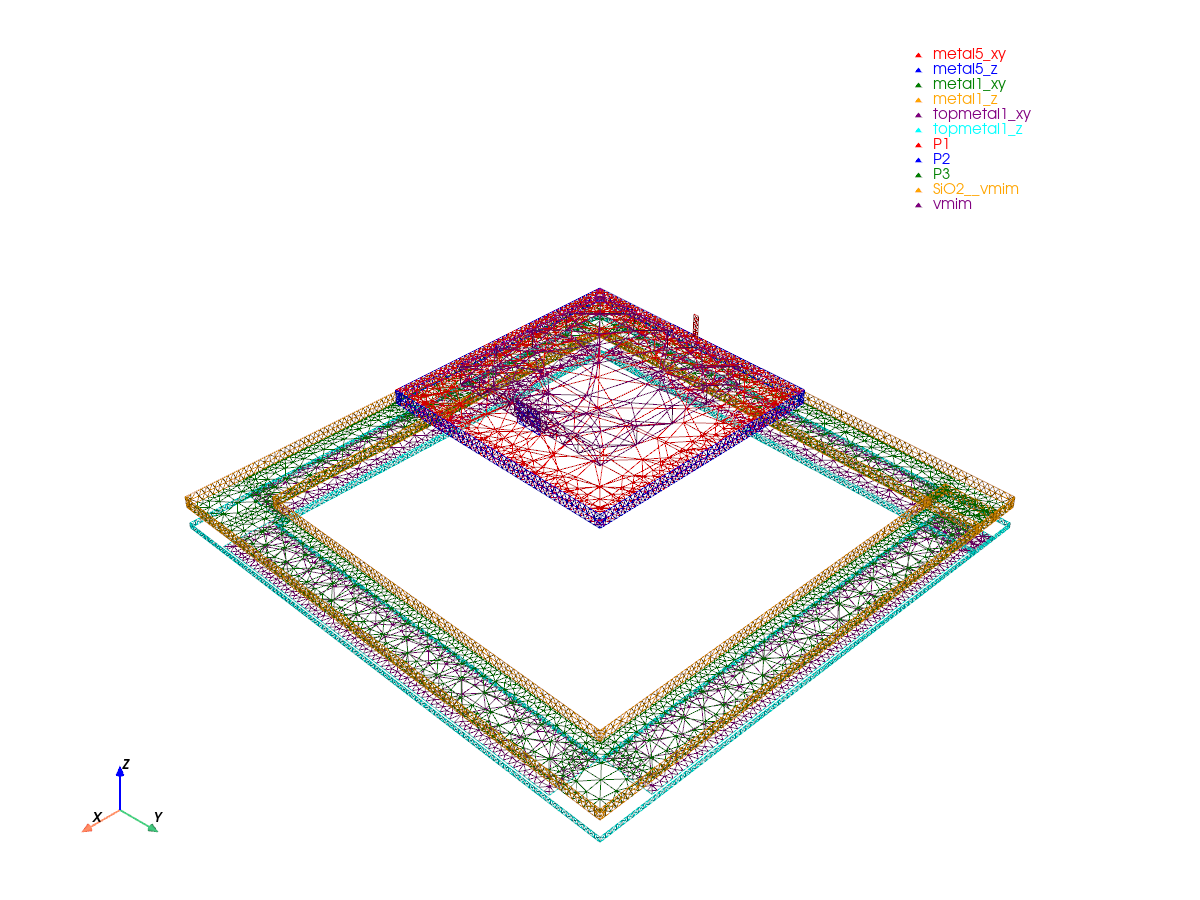

In [22]:
sim.plot_mesh(show_groups=["metal","active","vmim","P"],interactive=False)

In [ ]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["air__None","air__passive","SiO2__None","SiO2__passive","passive__None"],
)

In [23]:
results = sim.run(parent_dir="runs")

  palace-7600aca5  completed  2m 29s
Extracting results.tar.gz...
Downloaded 11 files to runs/sim-data-palace-7600aca5


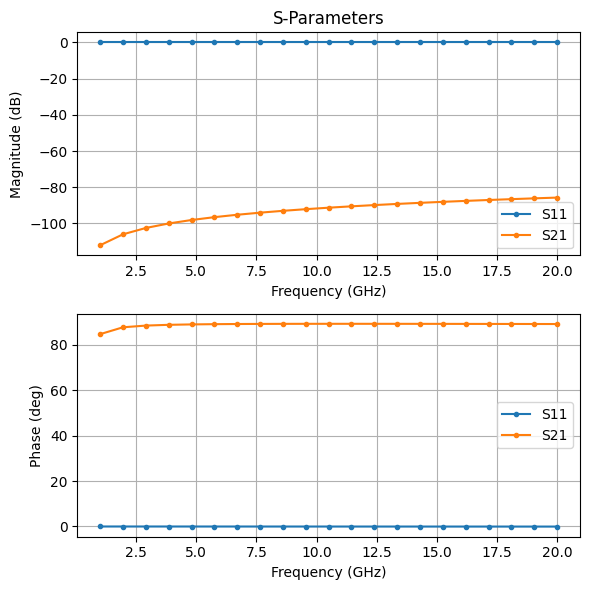

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()